# MILK10k — Exploratory Data Analysis

**Course:** Computer Vision & Speech Recognition · **Milestone 1**

## Clinical task

Classify a skin lesion into its diagnostic category from a **paired clinical
close-up + dermatoscopic image** and patient metadata, so that malignant lesions
(melanoma, BCC, SCC, …) are flagged for biopsy and benign ones are not over-treated.
Ground truth for ~96 % of lesions is **histopathology**.

This notebook answers four questions before any modelling:

1. **What is in the dataset?** — images, lesions, modalities, sources
2. **What does the metadata look like?** — completeness, age, sex, site, skin tone
3. **How are the classes distributed?** — 11 top-level classes, 48 fine diagnoses, imbalance
4. **What do the images look like?** — resolution, colour, per-class examples, MONET features

Dataset: [MILK10k on the ISIC Archive](https://api.isic-archive.com/doi/milk10k/) · DOI 10.34970/648456 · CC-BY-NC

## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import milk10k as mk

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# --- chart style: recessive axes/grid, thin marks, one validated palette -----
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b8b7b3", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.titleweight": "semibold", "axes.titlesize": 11,
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "legend.frameon": False,
})
BLUE, ORANGE, AQUA = mk.BLUE, mk.ORANGE, mk.AQUA
MAL_COLORS = {False: mk.BENIGN_COLOR, True: mk.MALIGNANT_COLOR}
mk.FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(mk.FIG_DIR / f"{name}.png")

print("data dir :", mk.DATA_DIR)
print("exists   :", mk.DATA_DIR.exists())

data dir : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k
exists   : True


## 2. Load the data

Four CSVs ship with the download. `metadata.csv`, `training_input.csv` and
`training_supp.csv` are **per image** (10,480 rows); `training_gt.csv` is
**per lesion** (5,240 rows, one-hot over 11 classes). `src/milk10k.py` merges
them into one per-image table and one per-lesion table.

In [2]:
meta = mk.load_metadata()
inp  = mk.load_training_input()
gt   = mk.load_training_gt()
supp = mk.load_training_supp()

for name, d in [("metadata.csv", meta), ("training_input.csv", inp),
                ("training_gt.csv", gt), ("training_supp.csv", supp)]:
    print(f"{name:22s} {d.shape[0]:>6,} rows × {d.shape[1]:>2} cols")

metadata.csv           10,480 rows × 17 cols
training_input.csv     10,480 rows × 17 cols
training_gt.csv         5,240 rows × 12 cols
training_supp.csv      10,480 rows ×  4 cols


In [3]:
images  = mk.load_images_table()     # one row per image
lesions = mk.load_lesions_table(images)  # one row per lesion
print("images :", images.shape, "| lesions :", lesions.shape)
images.head(3)

images : (10480, 32) | lesions : (5240, 14)


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen,diagnosis_full,invasion_thickness_interval,label,label_name,malignant,path
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male,4,upper_extremity,0.430286,0.582339,0.670489,0.192551,0.060440,0.359686,0.059682,"Squamous cell carcinoma, Invasive",NaN,SCCKA,Squamous cell carcinoma / keratoacanthoma,True,/Users/joshuacole/Desktop/School/AI/School/Com...
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female,3,trunk,0.214353,0.368319,0.050030,0.039891,0.884037,0.142474,0.345616,"Nevus, Reed",NaN,NV,Melanocytic nevus,False,/Users/joshuacole/Desktop/School/AI/School/Com...
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical,IL_9270970,True,female,3,upper_extremity,0.055999,0.065435,0.000887,0.052962,0.914881,0.081416,0.919572,"Nevus, Acral",NaN,NV,Melanocytic nevus,False,/Users/joshuacole/Desktop/School/AI/School/Com...


In [4]:
lesions.head(3)

,lesion_id,age_approx,sex,anatom_site_general,site,skin_tone_class,diagnosis_confirm_type,diagnosis_full,label,label_name,malignant,n_images,isic_id_clinical,isic_id_dermoscopic
0,IL_0000652,70.0,male,head/neck,head_neck_face,1,histopathology,Basal cell carcinoma,BCC,Basal cell carcinoma,True,2,ISIC_8149219,ISIC_4671410
1,IL_0003176,45.0,female,head/neck,head_neck_face,5,histopathology,Basal cell carcinoma,BCC,Basal cell carcinoma,True,2,ISIC_3904045,ISIC_5371928
2,IL_0004688,50.0,male,lower extremity,lower_extremity,3,histopathology,Basal cell carcinoma,BCC,Basal cell carcinoma,True,2,ISIC_0791494,ISIC_3624913


## 3. Dataset overview

In [5]:
n_img, n_les = len(images), images["lesion_id"].nunique()
per_lesion = images.groupby("lesion_id").size().value_counts().to_dict()
by_type = images["image_type"].value_counts().to_dict()
confirm = lesions["diagnosis_confirm_type"].value_counts(normalize=True).mul(100).round(1).to_dict()
files_on_disk = sum(1 for _ in mk.IMAGE_DIR.glob("*.jpg"))

overview = pd.Series({
    "images (rows)": n_img,
    "image files on disk": files_on_disk,
    "lesions": n_les,
    "images per lesion": per_lesion,
    "image types": by_type,
    "top-level classes": len(mk.CLASS_CODES),
    "fine diagnoses (diagnosis_full)": images["diagnosis_full"].nunique(),
    "ground truth (% of lesions)": confirm,
    "attribution": images["attribution"].unique().tolist(),
    "license": images["copyright_license"].unique().tolist(),
}, name="MILK10k")
overview.to_frame()

,MILK10k
images (rows),10480
image files on disk,10480
lesions,5240
images per lesion,{2: 5240}
image types,"{'dermoscopic': 5240, 'clinical': 5240}"
top-level classes,11
fine diagnoses (diagnosis_full),48
ground truth (% of lesions),"{'histopathology': 95.7, 'single contributor c..."
attribution,[MILK study team]
license,[CC-BY-NC]


Every lesion has exactly **one clinical close-up and one dermatoscopic image**, so
the natural unit for splitting and evaluating is the **lesion**, not the image —
otherwise both views of a lesion can leak across train/validation.

## 4. Metadata

### 4.1 Completeness

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


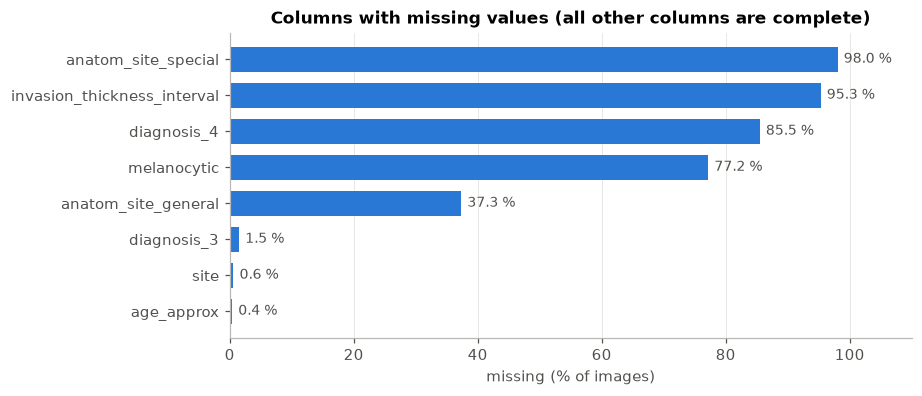

In [6]:
cols = [c for c in images.columns if c not in ("path",)]
missing = images[cols].isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(missing.index[::-1], missing.values[::-1], color=BLUE, height=0.7)
for y, v in enumerate(missing.values[::-1]):
    ax.text(v + 1, y, f"{v:.1f} %", va="center", fontsize=9, color="#52514e")
ax.set_xlim(0, 110); ax.set_xlabel("missing (% of images)")
ax.set_title("Columns with missing values (all other columns are complete)")
ax.grid(axis="y", visible=False)
save(fig, "04_missingness"); plt.show()

- `anatom_site_special`, `invasion_thickness_interval` (Breslow, melanoma only), `diagnosis_4`
  and `melanocytic` are *conditionally* populated — missing means "not applicable", not lost data.
- `anatom_site_general` is missing for 37 % of images, but the supplement column **`site`** is
  99.4 % complete and finer (adds trunk / hand / foot). Use `site`.
- Age is missing for only 0.4 % of images; sex and skin tone are complete.

### 4.2 Patient & acquisition attributes (per lesion)

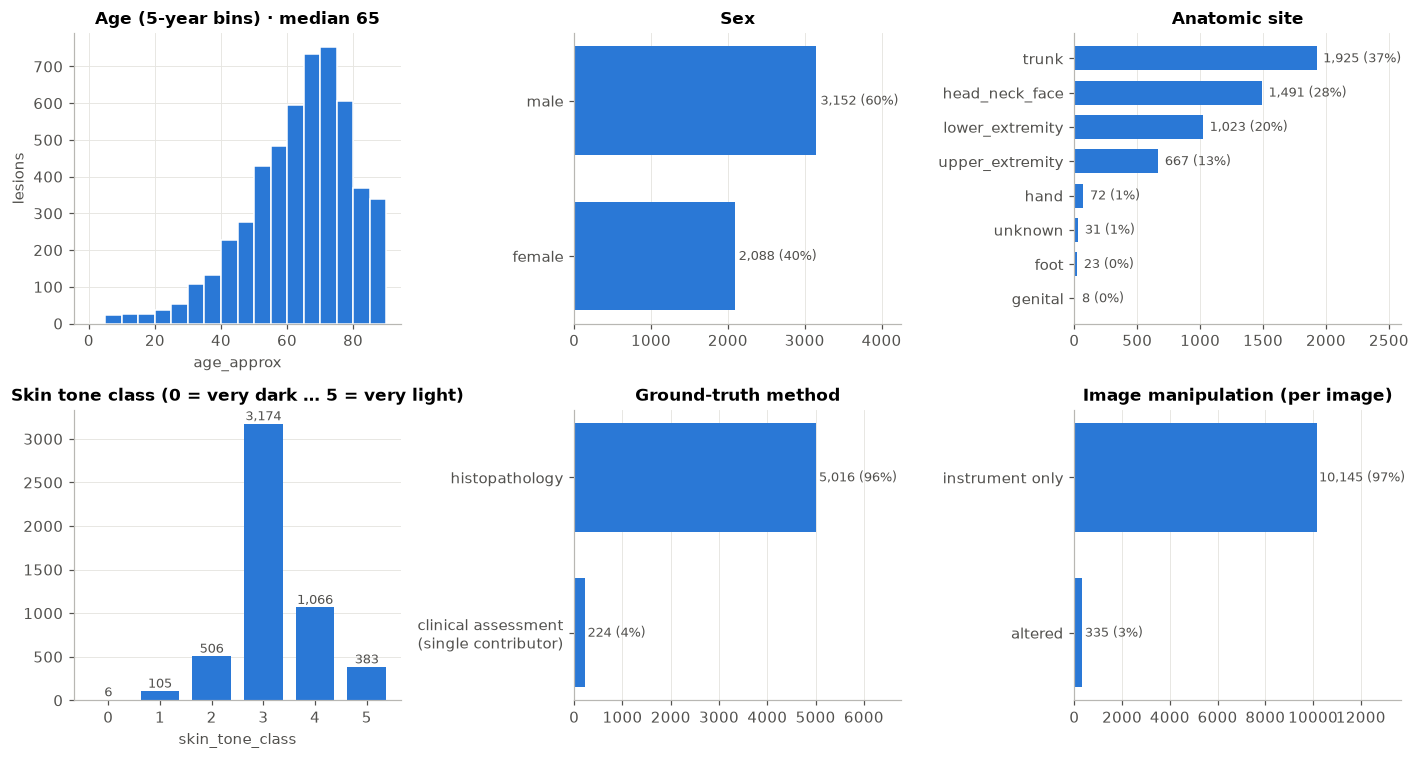

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

# age — histogram in the dataset's 5-year bins
ages = lesions["age_approx"].dropna()
axes[0].hist(ages, bins=np.arange(0, 91, 5), color=BLUE, edgecolor="white", linewidth=1)
axes[0].set_title(f"Age (5-year bins) · median {ages.median():.0f}")
axes[0].set_xlabel("age_approx"); axes[0].set_ylabel("lesions")

def bar(ax, s, title, color=BLUE, pct=True):
    s = s.sort_values(ascending=True)
    ax.barh(s.index.astype(str), s.values, color=color, height=0.7)
    tot = s.sum()
    for y, v in enumerate(s.values):
        ax.text(v + tot*0.01, y, f"{v:,}" + (f" ({v/tot:.0%})" if pct else ""), va="center", fontsize=8.5, color="#52514e")
    ax.set_xlim(0, s.max()*1.35); ax.set_title(title); ax.grid(axis="y", visible=False)

bar(axes[1], lesions["sex"].value_counts(), "Sex")
bar(axes[2], lesions["site"].fillna("unknown").value_counts(), "Anatomic site")
tone = lesions["skin_tone_class"].map(mk.SKIN_TONE_LABELS).value_counts().reindex(mk.SKIN_TONE_LABELS.values()).fillna(0).astype(int)
axes[3].bar([t.split()[0] for t in tone.index], tone.values, color=BLUE, width=0.75)
for x, v in enumerate(tone.values):
    axes[3].text(x, v + 40, f"{v:,}", ha="center", fontsize=8.5, color="#52514e")
axes[3].set_title("Skin tone class (0 = very dark … 5 = very light)"); axes[3].set_xlabel("skin_tone_class")
axes[3].grid(axis="x", visible=False)
bar(axes[4], lesions["diagnosis_confirm_type"].replace({"single contributor clinical assessment": "clinical assessment\n(single contributor)"}).value_counts(), "Ground-truth method")
bar(axes[5], images["image_manipulation"].value_counts(), "Image manipulation (per image)")
fig.tight_layout(); save(fig, "04_metadata_overview"); plt.show()

**Demographics are skewed.** Patients are mostly older (median age 65), 60 % male,
and 61 % are skin-tone class 3, with fewer than 1 % of lesions in the two darkest
classes (0–1). Any model trained here needs its performance reported **per skin
tone**, and generalisation to darker skin should be treated as unproven.

## 5. Class distribution

### 5.1 The 11 top-level classes

In [8]:
counts = lesions["label"].value_counts()
class_table = pd.DataFrame({
    "class": counts.index,
    "name": counts.index.map(mk.CLASS_NAMES),
    "lesions": counts.values,
    "share %": (counts.values / counts.sum() * 100).round(1),
    "malignant": [c in mk.MALIGNANT for c in counts.index],
}).reset_index(drop=True)
class_table["imbalance vs largest"] = (counts.max() / class_table["lesions"]).round(1).map(lambda r: f"1 : {r:g}")
class_table

,class,name,lesions,share %,malignant,imbalance vs largest
0,BCC,Basal cell carcinoma,2522,48.1,True,1 : 1
1,NV,Melanocytic nevus,746,14.2,False,1 : 3.4
2,BKL,Benign keratinocytic lesion,544,10.4,False,1 : 4.6
3,SCCKA,Squamous cell carcinoma / keratoacanthoma,473,9.0,True,1 : 5.3
4,MEL,Melanoma,450,8.6,True,1 : 5.6
5,AKIEC,Actinic keratosis / intraepidermal carcinoma,303,5.8,True,1 : 8.3
6,DF,Dermatofibroma,52,1.0,False,1 : 48.5
7,INF,Inflammatory / infectious,50,1.0,False,1 : 50.4
8,VASC,Vascular lesion / hemorrhage,47,0.9,False,1 : 53.7
9,BEN_OTH,Other benign proliferations,44,0.8,False,1 : 57.3


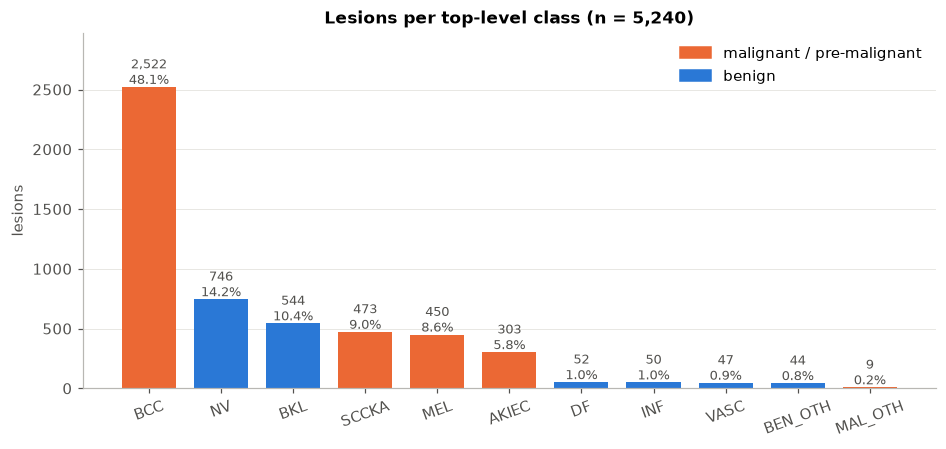

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
colors = [MAL_COLORS[c in mk.MALIGNANT] for c in counts.index]
ax.bar(counts.index, counts.values, color=colors, width=0.75)
for x, v in enumerate(counts.values):
    ax.text(x, v + 25, f"{v:,}\n{v/counts.sum():.1%}", ha="center", fontsize=8.5, color="#52514e")
ax.set_ylim(0, counts.max()*1.18); ax.set_ylabel("lesions"); ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=20)
ax.set_title(f"Lesions per top-level class (n = {counts.sum():,})")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=MAL_COLORS[True], label="malignant / pre-malignant"),
                   Patch(color=MAL_COLORS[False], label="benign")], loc="upper right")
save(fig, "05_class_distribution"); plt.show()

In [10]:
mal = lesions["malignant"].value_counts()
print(f"malignant: {mal[True]:,} lesions ({mal[True]/mal.sum():.1%})   benign: {mal[False]:,} ({mal[False]/mal.sum():.1%})")
print(f"largest class BCC : {counts['BCC']:,}  |  smallest MAL_OTH : {counts['MAL_OTH']}  |  ratio 1 : {counts['BCC']/counts['MAL_OTH']:.0f}")

malignant: 3,757 lesions (71.7%)   benign: 1,483 (28.3%)
largest class BCC : 2,522  |  smallest MAL_OTH : 9  |  ratio 1 : 280


**Key finding — this is not a screening population.** Basal cell carcinoma alone is
48 % of lesions and **72 % of lesions are malignant**; melanocytic nevi, which dominate
public dermoscopy datasets like HAM10000, are only 14 % here. The cohort is
biopsy-enriched (lesions clinicians already chose to excise). Consequences:

- Prevalence-dependent metrics (accuracy, PPV) will not transfer to a clinic population.
  Report **per-class sensitivity/specificity, balanced accuracy and macro-F1**.
- The tail is tiny: `MAL_OTH` (9), `BEN_OTH` (44), `VASC` (47), `INF` (50), `DF` (52).
  Stratified splits and class-weighted loss / re-sampling are required; consider merging
  `MAL_OTH`/`BEN_OTH` into an "other" bucket for a first model.

### 5.2 The diagnosis hierarchy (4 levels → 48 fine diagnoses)

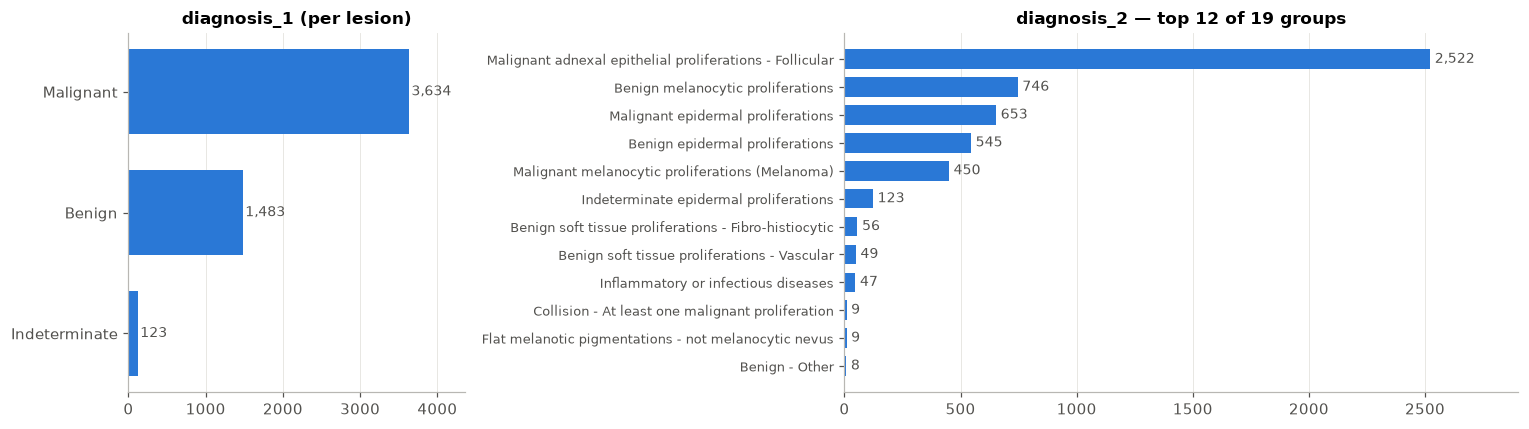

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 2]})
d1 = lesions.merge(images.drop_duplicates("lesion_id")[["lesion_id", "diagnosis_1", "diagnosis_2"]], on="lesion_id")
s1 = d1["diagnosis_1"].value_counts()
axes[0].barh(s1.index[::-1], s1.values[::-1], color=BLUE, height=0.7)
for y, v in enumerate(s1.values[::-1]):
    axes[0].text(v + 30, y, f"{v:,}", va="center", fontsize=9, color="#52514e")
axes[0].set_xlim(0, s1.max()*1.2); axes[0].set_title("diagnosis_1 (per lesion)"); axes[0].grid(axis="y", visible=False)

s2 = d1["diagnosis_2"].value_counts().head(12)
axes[1].barh(s2.index[::-1], s2.values[::-1], color=BLUE, height=0.7)
for y, v in enumerate(s2.values[::-1]):
    axes[1].text(v + 20, y, f"{v:,}", va="center", fontsize=9, color="#52514e")
axes[1].set_xlim(0, s2.max()*1.15); axes[1].set_title("diagnosis_2 — top 12 of %d groups" % d1["diagnosis_2"].nunique()); axes[1].grid(axis="y", visible=False)
axes[1].tick_params(axis="y", labelsize=8.5)
fig.tight_layout(); save(fig, "05_hierarchy_levels"); plt.show()

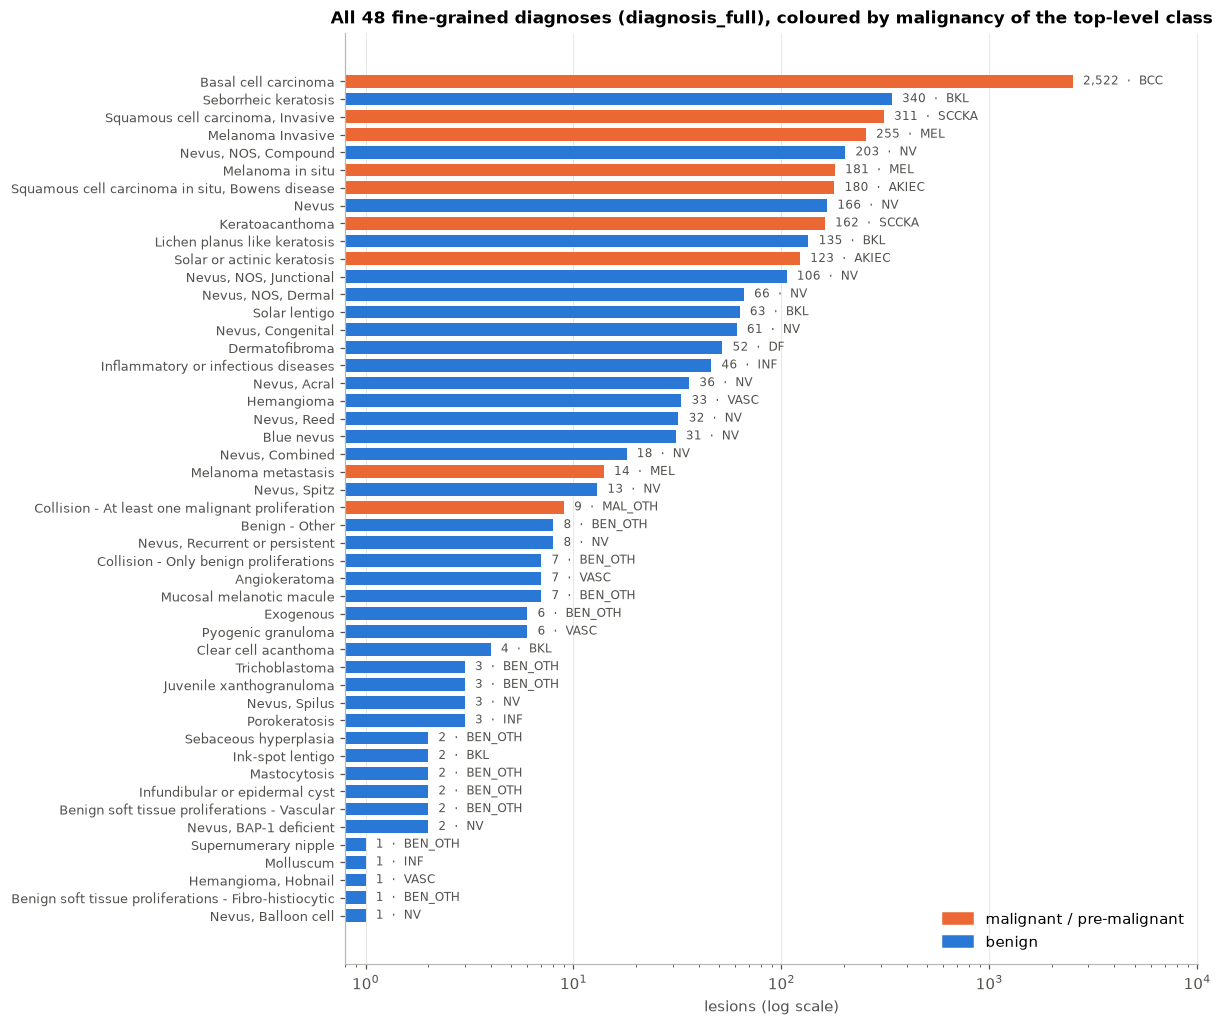

In [12]:
fine = lesions.groupby(["label", "diagnosis_full"]).size().reset_index(name="lesions")
fine["malignant"] = fine["label"].isin(mk.MALIGNANT)
fine = fine.sort_values("lesions", ascending=True)

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(fine["diagnosis_full"], fine["lesions"], color=fine["malignant"].map(MAL_COLORS), height=0.72)
ax.set_xscale("log"); ax.set_xlabel("lesions (log scale)")
for y, (v, lab) in enumerate(zip(fine["lesions"], fine["label"])):
    ax.text(v*1.12, y, f"{v:,}  ·  {lab}", va="center", fontsize=8, color="#52514e")
ax.set_xlim(0.8, fine["lesions"].max()*4); ax.tick_params(axis="y", labelsize=8.5); ax.grid(axis="y", visible=False)
ax.set_title(f"All {len(fine)} fine-grained diagnoses (diagnosis_full), coloured by malignancy of the top-level class")
ax.legend(handles=[Patch(color=MAL_COLORS[True], label="malignant / pre-malignant"), Patch(color=MAL_COLORS[False], label="benign")], loc="lower right")
save(fig, "05_fine_diagnoses"); plt.show()

In [13]:
print(f"{len(fine)} fine diagnoses · {(fine['lesions'] < 10).sum()} of them have fewer than 10 lesions · {(fine['lesions'] == 1).sum()} have exactly 1")
fine.sort_values("lesions", ascending=False).reset_index(drop=True).head(15)

48 fine diagnoses · 24 of them have fewer than 10 lesions · 5 have exactly 1


,label,diagnosis_full,lesions,malignant
0,BCC,Basal cell carcinoma,2522,True
1,BKL,Seborrheic keratosis,340,False
2,SCCKA,"Squamous cell carcinoma, Invasive",311,True
3,MEL,Melanoma Invasive,255,True
4,NV,"Nevus, NOS, Compound",203,False
5,MEL,Melanoma in situ,181,True
6,AKIEC,"Squamous cell carcinoma in situ, Bowens disease",180,True
7,NV,Nevus,166,False
8,SCCKA,Keratoacanthoma,162,True
9,BKL,Lichen planus like keratosis,135,False


The 48-way task is essentially unlearnable for the long tail (many diagnoses have
< 10 examples). The **11-class level is the right target**; the fine label is
useful for stratifying splits and for error analysis.

## 6. Class × metadata cross-tabs

Because the dataset comes from five centres in four countries, we want to know
whether any demographic or acquisition variable is a *proxy* for the label — a
model could learn that shortcut instead of the lesion.

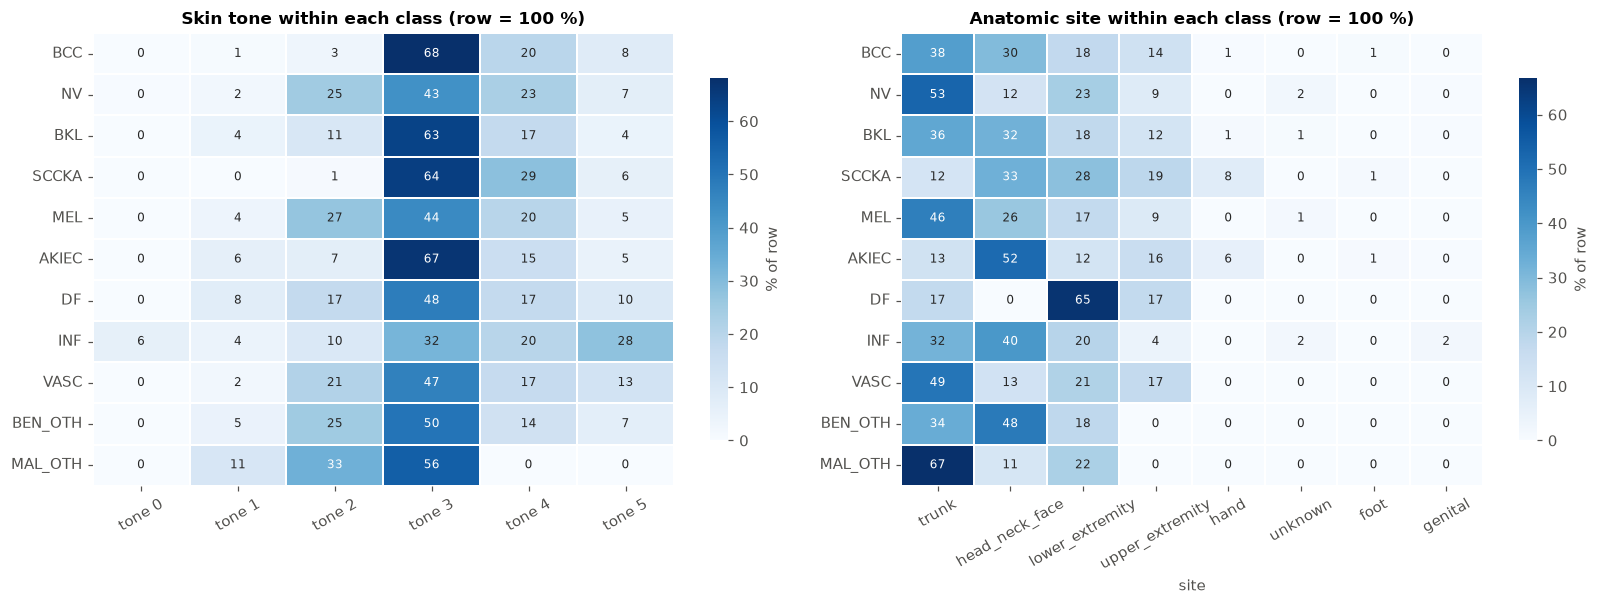

In [14]:
order = counts.index.tolist()

def heat(ax, ct, title, fmt=".0f", cbar_label="% of row"):
    sns.heatmap(ct, ax=ax, cmap=mk.SEQ_CMAP, annot=True, fmt=fmt, annot_kws={"size": 8},
                linewidths=1, linecolor="white", cbar_kws={"label": cbar_label, "shrink": 0.8})
    ax.set_title(title); ax.set_ylabel(""); ax.set_xlabel(ax.get_xlabel()); ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
ct_tone = pd.crosstab(lesions["label"], lesions["skin_tone_class"], normalize="index").mul(100).reindex(order)
ct_tone.columns = [f"tone {c}" for c in ct_tone.columns]
heat(axes[0], ct_tone, "Skin tone within each class (row = 100 %)")
site_order = lesions["site"].fillna("unknown").value_counts().index
ct_site = pd.crosstab(lesions["label"], lesions["site"].fillna("unknown"), normalize="index").mul(100).reindex(index=order, columns=site_order)
heat(axes[1], ct_site, "Anatomic site within each class (row = 100 %)")
fig.tight_layout(); save(fig, "06_class_by_tone_site"); plt.show()

/var/folders/gj/_0l_6h513cd07kyxvyxchbth0000gn/T/ipykernel_45631/1023528501.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([data[i] for i in med_order], vert=False, widths=0.55, patch_artist=True,


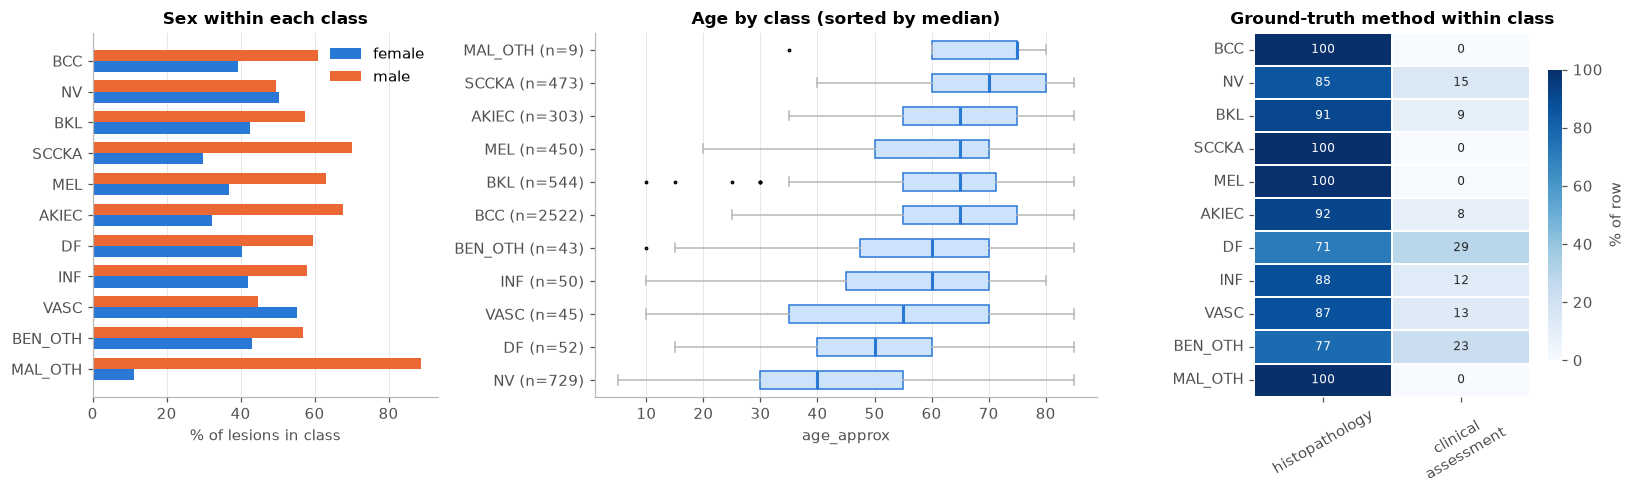

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.1, 1.6, 1.1]})

# sex within class — two series, legend + fixed colours (blue = female, orange = male)
ct_sex = pd.crosstab(lesions["label"], lesions["sex"], normalize="index").mul(100).reindex(order)
y = np.arange(len(order)); h = 0.36
axes[0].barh(y + h/2, ct_sex["female"], height=h, color=BLUE, label="female")
axes[0].barh(y - h/2, ct_sex["male"],   height=h, color=ORANGE, label="male")
axes[0].set_yticks(y, order); axes[0].invert_yaxis(); axes[0].set_xlabel("% of lesions in class")
axes[0].set_title("Sex within each class"); axes[0].legend(loc="upper right"); axes[0].grid(axis="y", visible=False)

# age by class — box plots ordered by median
data = [lesions.loc[lesions["label"] == c, "age_approx"].dropna() for c in order]
med_order = np.argsort([d.median() for d in data])
axes[1].boxplot([data[i] for i in med_order], vert=False, widths=0.55, patch_artist=True,
                boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE, linewidth=1), medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color="#b8b7b3"), capprops=dict(color="#b8b7b3"), flierprops=dict(marker=".", markersize=3, color="#b8b7b3"))
axes[1].set_yticks(range(1, len(order)+1), [f"{order[i]} (n={len(data[i])})" for i in med_order])
axes[1].set_xlabel("age_approx"); axes[1].set_title("Age by class (sorted by median)"); axes[1].grid(axis="y", visible=False)

# ground-truth method within class
ct_gt = pd.crosstab(lesions["label"], lesions["diagnosis_confirm_type"], normalize="index").mul(100).reindex(order)
ct_gt.columns = ["clinical\nassessment" if "clinical" in c else c for c in ct_gt.columns]
heat(axes[2], ct_gt, "Ground-truth method within class")
fig.tight_layout(); save(fig, "06_class_by_sex_age_gt"); plt.show()

Observations:

- **Age is strongly class-dependent** — keratinocyte cancers (BCC, SCC, AK) have median
  ages of 65–70, nevi ~40, vascular lesions and dermatofibromas ~50–55. Age is a legitimate
  clinical prior, but a model that leans on it will fail on the young-BCC / old-nevus cases;
  check errors by age band.
- **Skin tone is a partial label proxy.** Keratinocyte cancers (BCC, SCCKA, AKIEC) are
  almost entirely tone 3–4, whereas ~25 % of NV and MEL patients are tone 2 and INF has
  the only tone-0 patients. Tone-stratified evaluation is mandatory.
- **Site** varies as expected clinically (BCC/AK on head & neck, nevi & melanoma on trunk).
- **Ground truth:** nearly every malignant class is 100 % histopathology; the benign
  classes (`NV`, `BKL`, `VASC`, `DF`) contain the clinically-assessed lesions. A model's
  "benign" errors are therefore judged against a slightly weaker label.

## 7. Images

### 7.1 Resolution, aspect ratio and file size (all 10,480 files, header read only)

In [16]:
def header(p):
    with Image.open(p) as im:
        w, h = im.size
        mode = im.mode
    return w, h, mode, p.stat().st_size / 1024

hdr = pd.DataFrame([header(p) for p in images["path"]], columns=["width", "height", "mode", "kb"], index=images.index)
images = images.join(hdr)
images["aspect"] = images["width"] / images["height"]
images["megapixels"] = images["width"] * images["height"] / 1e6
print("modes:", images["mode"].value_counts().to_dict())
images.groupby("image_type")[["width", "height", "aspect", "megapixels", "kb"]].describe().T.round(2)

modes: {'RGB': 10480}


image_type        clinical  dermoscopic
width      count   5240.00      5240.00
           mean     600.00       600.00
           std        0.00         0.00
           min      600.00       600.00
           25%      600.00       600.00
           50%      600.00       600.00
           75%      600.00       600.00
           max      600.00       600.00
height     count   5240.00      5240.00
           mean     450.00       450.00
           std        0.00         0.00
           min      450.00       450.00
           25%      450.00       450.00
           50%      450.00       450.00
           75%      450.00       450.00
           max      450.00       450.00
aspect     count   5240.00      5240.00
           mean       1.33         1.33
           std        0.00         0.00
           min        1.33         1.33
           25%        1.33         1.33
           50%        1.33         1.33
           75%        1.33         1.33
           max        1.33         1.33
megapixels count   5240.00      5240.00
           mean       0.27         0.27
           std        0.00         0.00
           min        0.27         0.27
           25%        0.27         0.27
           50%        0.27         0.27
           75%        0.27         0.27
           max        0.27         0.27
kb         count   5240.00      5240.00
           mean      39.14        26.95
           std        9.67         6.53
           min       11.54        12.16
           25%       33.12        22.74
           50%       38.77        26.00
           75%       44.82        30.14
           max       99.10        74.10

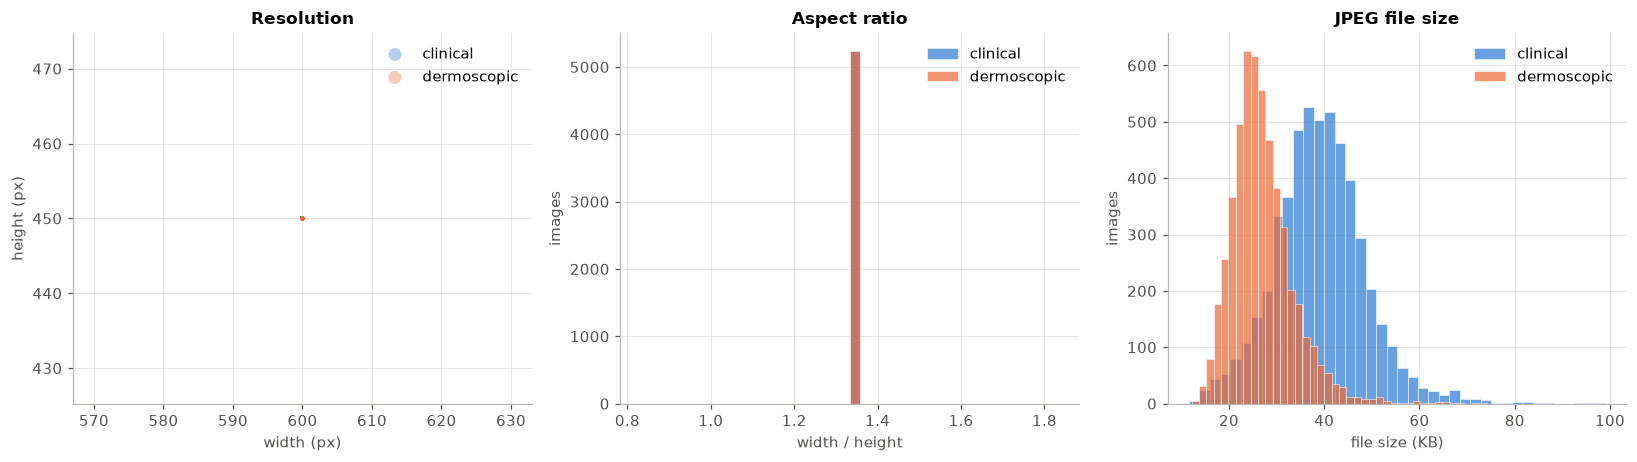

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
types = ["clinical", "dermoscopic"]; tcol = {"clinical": BLUE, "dermoscopic": ORANGE}

for t in types:
    sub = images[images["image_type"] == t]
    axes[0].scatter(sub["width"], sub["height"], s=8, alpha=0.35, color=tcol[t], label=t, edgecolors="none")
axes[0].set_xlabel("width (px)"); axes[0].set_ylabel("height (px)"); axes[0].set_title("Resolution"); axes[0].legend(markerscale=3)

for t in types:
    sub = images[images["image_type"] == t]
    axes[1].hist(sub["aspect"], bins=40, color=tcol[t], alpha=0.7, label=t, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("width / height"); axes[1].set_ylabel("images"); axes[1].set_title("Aspect ratio"); axes[1].legend()

for t in types:
    sub = images[images["image_type"] == t]
    axes[2].hist(sub["kb"], bins=40, color=tcol[t], alpha=0.7, label=t, edgecolor="white", linewidth=0.5)
axes[2].set_xlabel("file size (KB)"); axes[2].set_ylabel("images"); axes[2].set_title("JPEG file size"); axes[2].legend()
fig.tight_layout(); save(fig, "07_image_geometry"); plt.show()

In [18]:
res = images.groupby(["image_type", "width", "height"]).size().reset_index(name="images").sort_values("images", ascending=False)
print("distinct (type, width, height) combinations:", len(res))
res.head(10)

distinct (type, width, height) combinations: 2


,image_type,width,height,images
0,clinical,600,450,5240
1,dermoscopic,600,450,5240


### 7.2 Colour statistics (random sample of 500 images per modality)

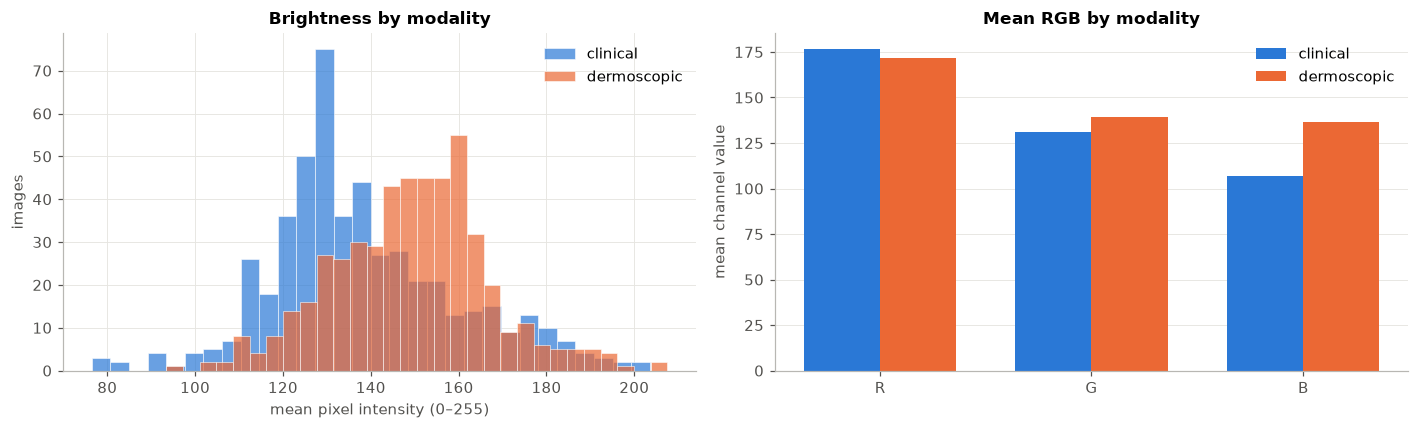

,R,G,B,brightness
image_type,,,,
clinical,176.500000,131.000000,106.699997,138.100006
dermoscopic,171.800003,139.399994,136.399994,149.199997


In [19]:
sample = images.groupby("image_type").sample(500, random_state=0)

def mean_rgb(p):
    with Image.open(p) as im:
        im.draft("RGB", (96, 96))          # fast JPEG decode at reduced size
        arr = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32)
    return arr.reshape(-1, 3).mean(axis=0)

rgb = np.vstack([mean_rgb(p) for p in sample["path"]])
sample = sample.assign(R=rgb[:, 0], G=rgb[:, 1], B=rgb[:, 2], brightness=rgb.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for t in types:
    sub = sample[sample["image_type"] == t]
    axes[0].hist(sub["brightness"], bins=30, color=tcol[t], alpha=0.7, label=t, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("mean pixel intensity (0–255)"); axes[0].set_ylabel("images"); axes[0].set_title("Brightness by modality"); axes[0].legend()

chan = sample.groupby("image_type")[["R", "G", "B"]].mean()
x = np.arange(3); w = 0.36
axes[1].bar(x - w/2, chan.loc["clinical"], width=w, color=BLUE, label="clinical")
axes[1].bar(x + w/2, chan.loc["dermoscopic"], width=w, color=ORANGE, label="dermoscopic")
axes[1].set_xticks(x, ["R", "G", "B"]); axes[1].set_ylabel("mean channel value"); axes[1].set_title("Mean RGB by modality"); axes[1].legend(); axes[1].grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "07_colour_stats"); plt.show()
sample.groupby("image_type")[["R", "G", "B", "brightness"]].mean().round(1)

### 7.3 One lesion per class — clinical close-up vs dermatoscopy

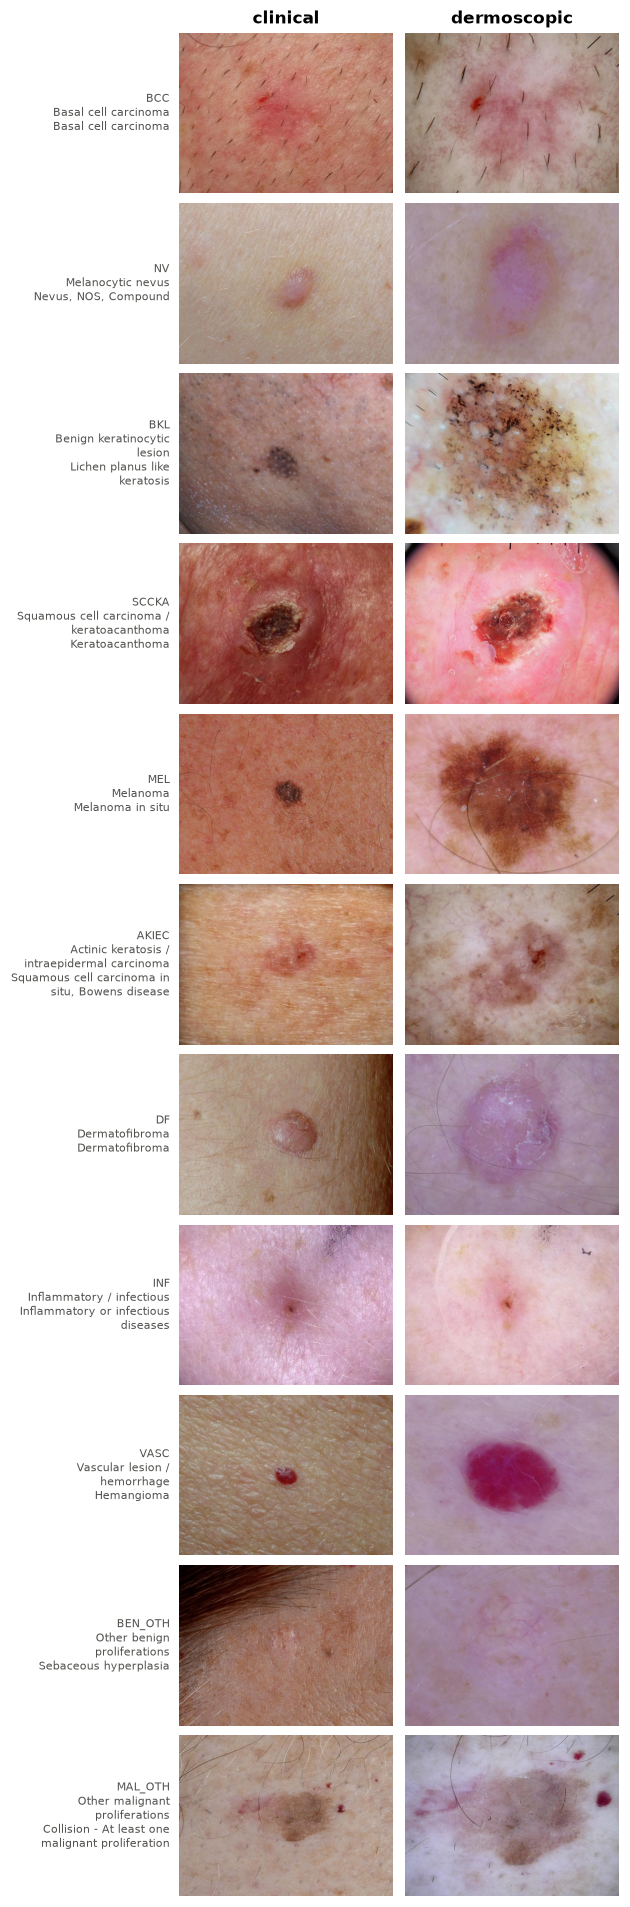

In [20]:
import textwrap
fig, axes = plt.subplots(len(order), 2, figsize=(5.2, 2.0 * len(order)))
for row, c in enumerate(order):
    les = lesions[lesions["label"] == c].sample(1, random_state=7).iloc[0]
    for col, t in enumerate(types):
        p = mk.IMAGE_DIR / f"{les['isic_id_' + t]}.jpg"
        with Image.open(p) as im:
            im.draft("RGB", (512, 512)); axes[row, col].imshow(im.convert("RGB"))
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([]); axes[row, col].grid(False)
        for s in axes[row, col].spines.values(): s.set_visible(False)
        if row == 0: axes[row, col].set_title(t)
    lab = f"{c}\n" + textwrap.fill(mk.CLASS_NAMES[c], 26) + "\n" + textwrap.fill(les["diagnosis_full"], 26)
    axes[row, 0].set_ylabel(lab, fontsize=7.5, rotation=0, ha="right", va="center", labelpad=6)
fig.subplots_adjust(wspace=0.04, hspace=0.06)
save(fig, "07_examples_per_class"); plt.show()

### 7.4 Random mosaic of dermatoscopic images

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


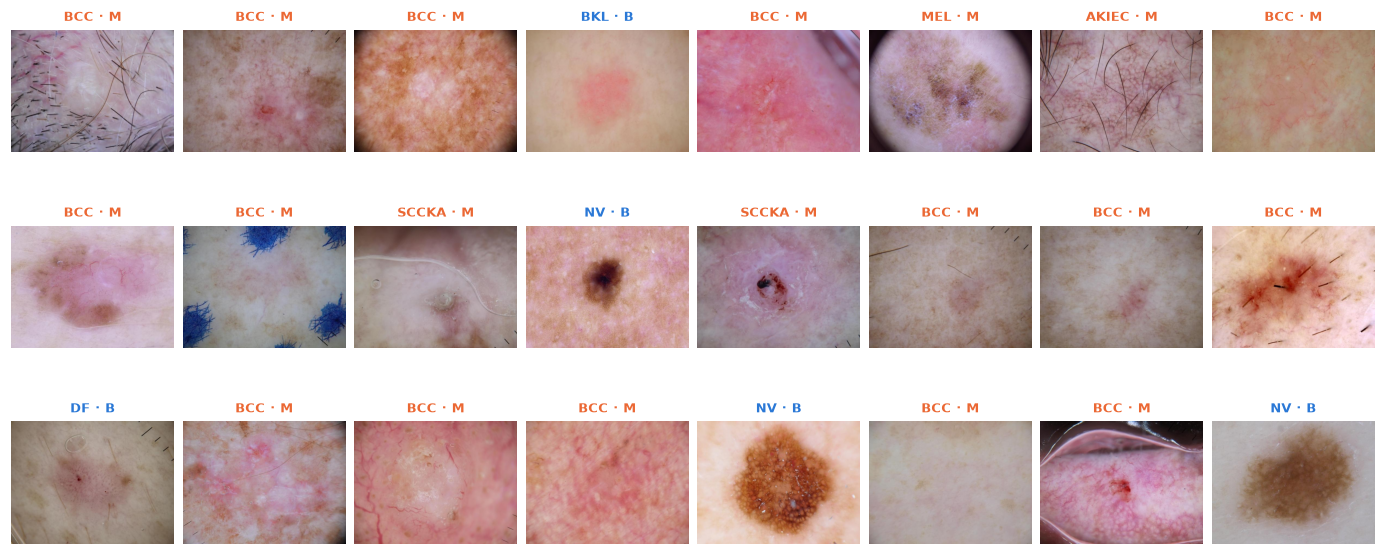

In [21]:
mos = images[images["image_type"] == "dermoscopic"].sample(24, random_state=3)
fig, axes = plt.subplots(3, 8, figsize=(16, 6.4))
for ax, (_, r) in zip(axes.ravel(), mos.iterrows()):
    with Image.open(r["path"]) as im:
        im.draft("RGB", (256, 256)); ax.imshow(im.convert("RGB"))
    ax.set_title(f"{r['label']} · {'M' if r['malignant'] else 'B'}", fontsize=8.5, color=MAL_COLORS[r["malignant"]])
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
fig.subplots_adjust(wspace=0.05, hspace=0.3); save(fig, "07_mosaic_dermoscopic"); plt.show()

## 8. MONET feature scores

`training_input.csv` ships seven **MONET** scores per image — a vision-language model's
probability that a clinical concept is present (ulceration, hair, vessels, erythema,
pigmentation, gel/fluid, pen markings). They are useful both as auxiliary inputs and
as a sanity check that the images carry the expected clinical signal.

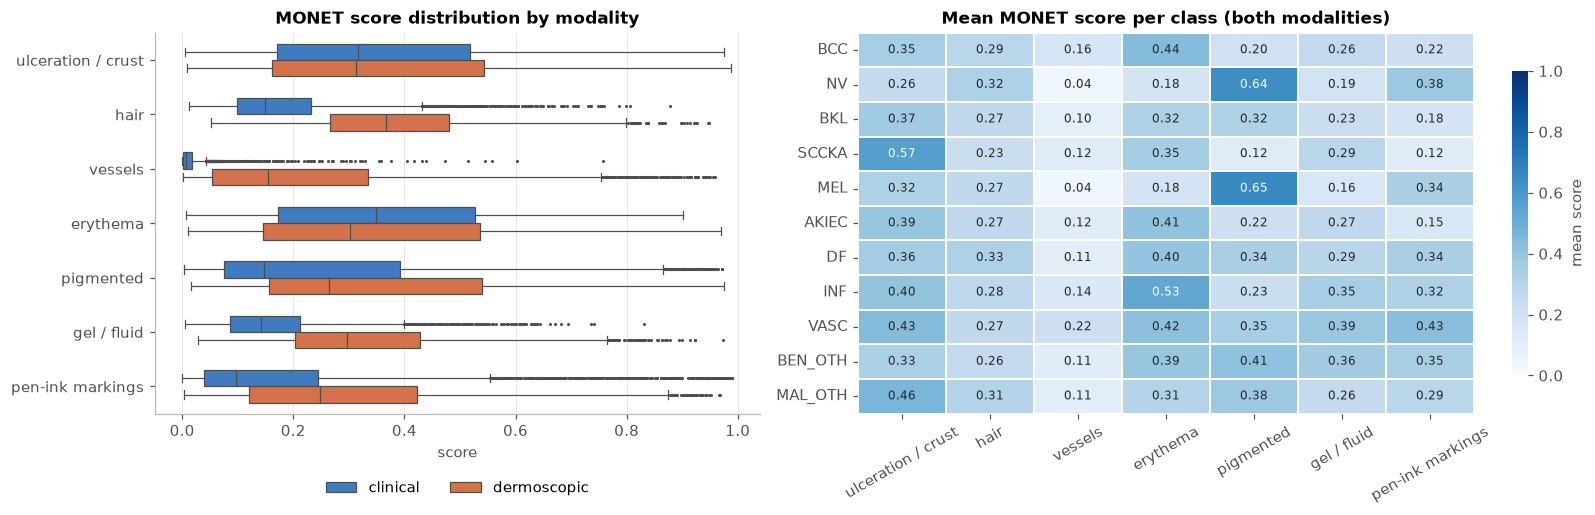

In [22]:
monet = [c for c in images.columns if c.startswith("MONET_")]
short = {"MONET_ulceration_crust": "ulceration / crust", "MONET_hair": "hair", "MONET_vasculature_vessels": "vessels",
         "MONET_erythema": "erythema", "MONET_pigmented": "pigmented",
         "MONET_gel_water_drop_fluid_dermoscopy_liquid": "gel / fluid", "MONET_skin_markings_pen_ink_purple_pen": "pen-ink markings"}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.1, 1.4]})
long = images.melt(id_vars=["image_type"], value_vars=monet, var_name="feature", value_name="score")
long["feature"] = long["feature"].map(short)
sns.boxplot(data=long, y="feature", x="score", hue="image_type", hue_order=types, palette=tcol, ax=axes[0],
            width=0.6, fliersize=1, linewidth=0.8)
axes[0].set_title("MONET score distribution by modality"); axes[0].set_ylabel(""); axes[0].grid(axis="y", visible=False)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)

mean_by_class = images.groupby("label")[monet].mean().reindex(order).rename(columns=short)
sns.heatmap(mean_by_class, ax=axes[1], cmap=mk.SEQ_CMAP, annot=True, fmt=".2f", annot_kws={"size": 8}, vmin=0, vmax=1,
            linewidths=1, linecolor="white", cbar_kws={"label": "mean score", "shrink": 0.8})
axes[1].set_title("Mean MONET score per class (both modalities)"); axes[1].set_ylabel(""); axes[1].tick_params(axis="x", rotation=30); axes[1].grid(False)
fig.tight_layout(); save(fig, "08_monet_features"); plt.show()

The scores behave as a dermatologist would expect — pigmentation is highest for
`NV`/`MEL` (~0.65), ulceration/crust for `SCCKA` (0.57), erythema for `INF`/`BCC`,
vessels for `VASC`, and the gel/fluid and hair scores are much higher on dermatoscopic
images (acquisition artefacts of the modality). Pen-marking scores are non-trivial, so **ink is a
potential shortcut** (marked lesions are often the suspicious ones) worth checking in
error analysis.

## 9. Summary of findings → implications for modelling

In [23]:
summary = {
    "lesions / images": f"{n_les:,} / {n_img:,}  (exactly 1 clinical + 1 dermatoscopic per lesion)",
    "classes": f"{len(order)} top-level · {images['diagnosis_full'].nunique()} fine-grained",
    "malignant share": f"{mal[True]/mal.sum():.1%} of lesions",
    "largest / smallest class": f"BCC {counts['BCC']:,} / MAL_OTH {counts['MAL_OTH']}  (1 : {counts['BCC']/counts['MAL_OTH']:.0f})",
    "ground truth": f"{confirm['histopathology']:.1f} % histopathology",
    "age": f"median {ages.median():.0f}, IQR {ages.quantile(.25):.0f}–{ages.quantile(.75):.0f}",
    "sex": f"{lesions['sex'].value_counts(normalize=True)['male']:.0%} male",
    "skin tone": f"{(lesions['skin_tone_class']==3).mean():.0%} class 3 · {(lesions['skin_tone_class']<=1).mean():.1%} classes 0–1",
    "image size": f"{int(images['width'].median())}×{int(images['height'].median())} px median · {images['megapixels'].min():.2f}–{images['megapixels'].max():.2f} MP",
    "distinct resolutions": len(res),
}
pd.Series(summary, name="MILK10k").to_frame()

,MILK10k
lesions / images,"5,240 / 10,480 (exactly 1 clinical + 1 dermat..."
classes,11 top-level · 48 fine-grained
malignant share,71.7% of lesions
largest / smallest class,"BCC 2,522 / MAL_OTH 9 (1 : 280)"
ground truth,95.7 % histopathology
age,"median 65, IQR 50–75"
sex,60% male
skin tone,61% class 3 · 2.1% classes 0–1
image size,600×450 px median · 0.27–0.27 MP
distinct resolutions,2


| Finding | What to do about it |
|---|---|
| Two images per lesion; 5,240 lesions | **Split by `lesion_id`**, never by image. Model the pair jointly (two-stream or late fusion) or train per-modality and fuse. |
| 72 % malignant, BCC = 48 %; five classes < 55 lesions | Stratified splits; class-weighted loss or balanced sampling; **macro-F1 / balanced accuracy / per-class sensitivity**, not accuracy. Consider folding `MAL_OTH`+`BEN_OTH` into "other" initially. |
| 48 fine diagnoses, most with < 10 examples | Train on the **11-class** level; use fine labels only for stratification and error analysis. |
| Older, male, tone-3-heavy cohort; almost no dark skin | Report metrics per skin tone and age band; do not claim generalisation to darker skin. |
| Age and site vary systematically by class | Legitimate priors — include as tabular inputs, but audit for over-reliance (young BCC, old nevus). |
| Benign classes contain the clinically-assessed (non-biopsied) lesions | Slightly noisier benign labels; weight "benign" errors accordingly. |
| Mixed resolutions and aspect ratios; dermatoscopy brighter and more saturated | Resize with aspect-preserving crop/pad; normalise per modality; dermoscopy-specific augmentations (hair, gel, rotation). |
| MONET pen-ink score is non-trivial | Check whether ink markings correlate with malignancy — a classic shortcut. |